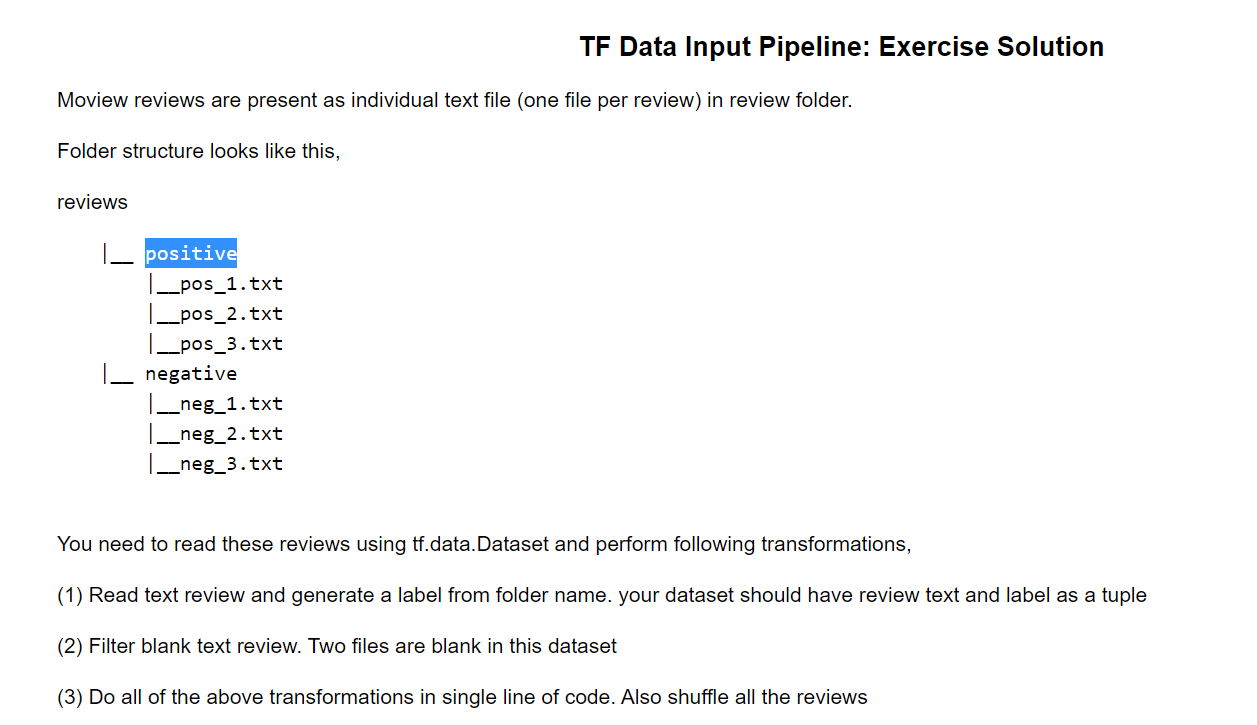

## TF Data Input Pipeline: Exercise Solution

Moview reviews are present as individual text file (one file per review) in review folder.

Folder structure looks like this,

reviews

|__ positive
    |__pos_1.txt
    |__pos_2.txt
    |__pos_3.txt
    
    
|__ negative
    |__neg_1.txt
    |__neg_2.txt
    |__neg_3.txt

You need to read these reviews using tf.data.Dataset and perform following transformations,

(1) Read text review and generate a label from folder name. your dataset should have review text and label as a tuple

(2) Filter blank text review. Two files are blank in this dataset

(3) Do all of the above transformations in single line of code. Also shuffle all the reviews

In [1]:
import tensorflow as tf

In [2]:
reviews_ds = tf.data.Dataset.list_files('reviews/*/*', shuffle=False)
# Read the data without shuffle

In [3]:
for file in reviews_ds:
    print(file.numpy())

b'reviews\\negative\\neg_1.txt.txt'
b'reviews\\negative\\neg_2.txt.txt'
b'reviews\\negative\\neg_3.txt.txt'
b'reviews\\positive\\pos_1.txt.txt'
b'reviews\\positive\\pos_2.txt.txt'
b'reviews\\positive\\pos_3.txt.txt'


## Extract review text from these files. Extract label from folder name

- Here create one funct which read full path and returns **review** as one value and **label/Y/Folder name** as 2nd value
- **tf.strings.split(file_path, os.path.sep)[-2]** This part gives subfolder name 'negative' and 'positive' as label

In [6]:
import os
def extract_review_and_label(file_path):
    return tf.io.read_file(file_path), tf.strings.split(file_path, os.path.sep)[-2]

##### Applied this function on all the reviews txt file

In [7]:
reviews_ds_1 = reviews_ds.map(extract_review_and_label)

for review, label in reviews_ds_1:
    print("Review: ",review.numpy()[:50])
    print("Label: ",label.numpy())

Review:  b"Basically there's a family where a little boy (Jak"
Label:  b'negative'
Review:  b'This show was an amazing, fresh & innovative idea '
Label:  b'negative'
Review:  b''
Label:  b'negative'
Review:  b'\r\nOne of the other reviewers has mentioned that af'
Label:  b'positive'
Review:  b'A wonderful little production. <br /><br />The fil'
Label:  b'positive'
Review:  b''
Label:  b'positive'


### Filter blank reviews

- **reviews_ds_1** has 2 values review and label, while applieng **filter** or **map**, it reads separately

In [8]:
reviews_ds_2 = reviews_ds_1.filter(lambda review, label: review!="")

for review, label in reviews_ds_2.as_numpy_iterator():
    print("Review: ",review[:50])
    print("Label: ",label)

Review:  b"Basically there's a family where a little boy (Jak"
Label:  b'negative'
Review:  b'This show was an amazing, fresh & innovative idea '
Label:  b'negative'
Review:  b'\r\nOne of the other reviewers has mentioned that af'
Label:  b'positive'
Review:  b'A wonderful little production. <br /><br />The fil'
Label:  b'positive'


### Perform map, filter and shuffle all in single line of code

In [9]:
final_ds = reviews_ds.map(extract_review_and_label).filter(lambda review, label: review!="").shuffle(3)
for review, label in final_ds.as_numpy_iterator():
    print("Review:",review[:50])
    print("Label:",label)

Review: b"Basically there's a family where a little boy (Jak"
Label: b'negative'
Review: b'\r\nOne of the other reviewers has mentioned that af'
Label: b'positive'
Review: b'A wonderful little production. <br /><br />The fil'
Label: b'positive'
Review: b'This show was an amazing, fresh & innovative idea '
Label: b'negative'


### TRAIN THE MODEL

- Pass this numeric converted **train_x**  or **review** and **Y** or **label.numpy()** to train the model